# Bouncing Ball Benchmark — Analysis & Visualisation

Analyses two CSV files produced by the C++ benchmark:
- **`benchmark.csv`** — aggregated metrics per (solver, dt)
- **`energy_drift.csv`** — E(t) time series for selected dt values

Plots produced:
1. Peak height error vs dt — convergence order
2. Max energy drift vs dt
3. Cost vs precision (ops_total vs height error)
4. CPU time vs dt
5. Bounce count vs dt — solver stability
6. E(t) time series
7. Summary statistics table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

SOLVER_STYLE = {
    "Euler":  {"color": "#E24B4A", "marker": "o", "ls": "-"},
    "Verlet": {"color": "#378ADD", "marker": "s", "ls": "--"},
    "RK4":    {"color": "#1D9E75", "marker": "^", "ls": "-."},
}
ABOX = dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", alpha=0.92, lw=0.8)

def solver_legend(ax, loc="lower right"):
    handles = [
        Line2D([0],[0], color=s["color"], marker=s["marker"],
               linestyle=s["ls"], label=name, markersize=6)
        for name, s in SOLVER_STYLE.items()
    ]
    ax.legend(handles=handles, framealpha=0.5, loc=loc)

# Analytical parameters (must match the C++ benchmark)
Z0          = 20.0
RADIUS      = 2.0
RESTITUTION = 0.9
G           = 9.81

def analytical_peak(n):
    """Analytical peak height after bounce n (1-indexed)."""
    return RADIUS + (Z0 - RADIUS) * RESTITUTION ** (2 * n)

BENCHMARK_CSV    = Path("benchmark.csv")
ENERGY_DRIFT_CSV = Path("energy_drift.csv")

df  = pd.read_csv(BENCHMARK_CSV)
ede = pd.read_csv(ENERGY_DRIFT_CSV)

# Convert cpu_us to ms for readability
df["cpu_ms"] = df["cpu_us"] / 1000.0

print(f"benchmark.csv    : {len(df)} rows  ({df['solver'].nunique()} solvers, {df['dt'].nunique()} dt values)")
print(f"energy_drift.csv : {len(ede)} rows")
df.head()

benchmark.csv    : 150 rows  (3 solvers, 50 dt values)
energy_drift.csv : 6597 rows


,solver,dt,max_height_error,max_energy_drift,final_energy_drift,cpu_us,ops_total,bounce_count,cpu_ms
0,Euler,0.500000,0.0,2.45250,2.45250,75.0,40,0,0.075
1,Euler,0.400934,0.0,1.93175,1.93175,62.0,49,0,0.062
2,Euler,0.321496,0.0,1.57163,1.57163,79.0,62,0,0.079
3,Euler,0.257797,0.0,1.25503,1.25503,98.0,77,0,0.098
4,Euler,0.206719,0.0,1.00610,1.00610,122.0,96,0,0.122


## Plot 1 — Peak height error vs dt (convergence order)

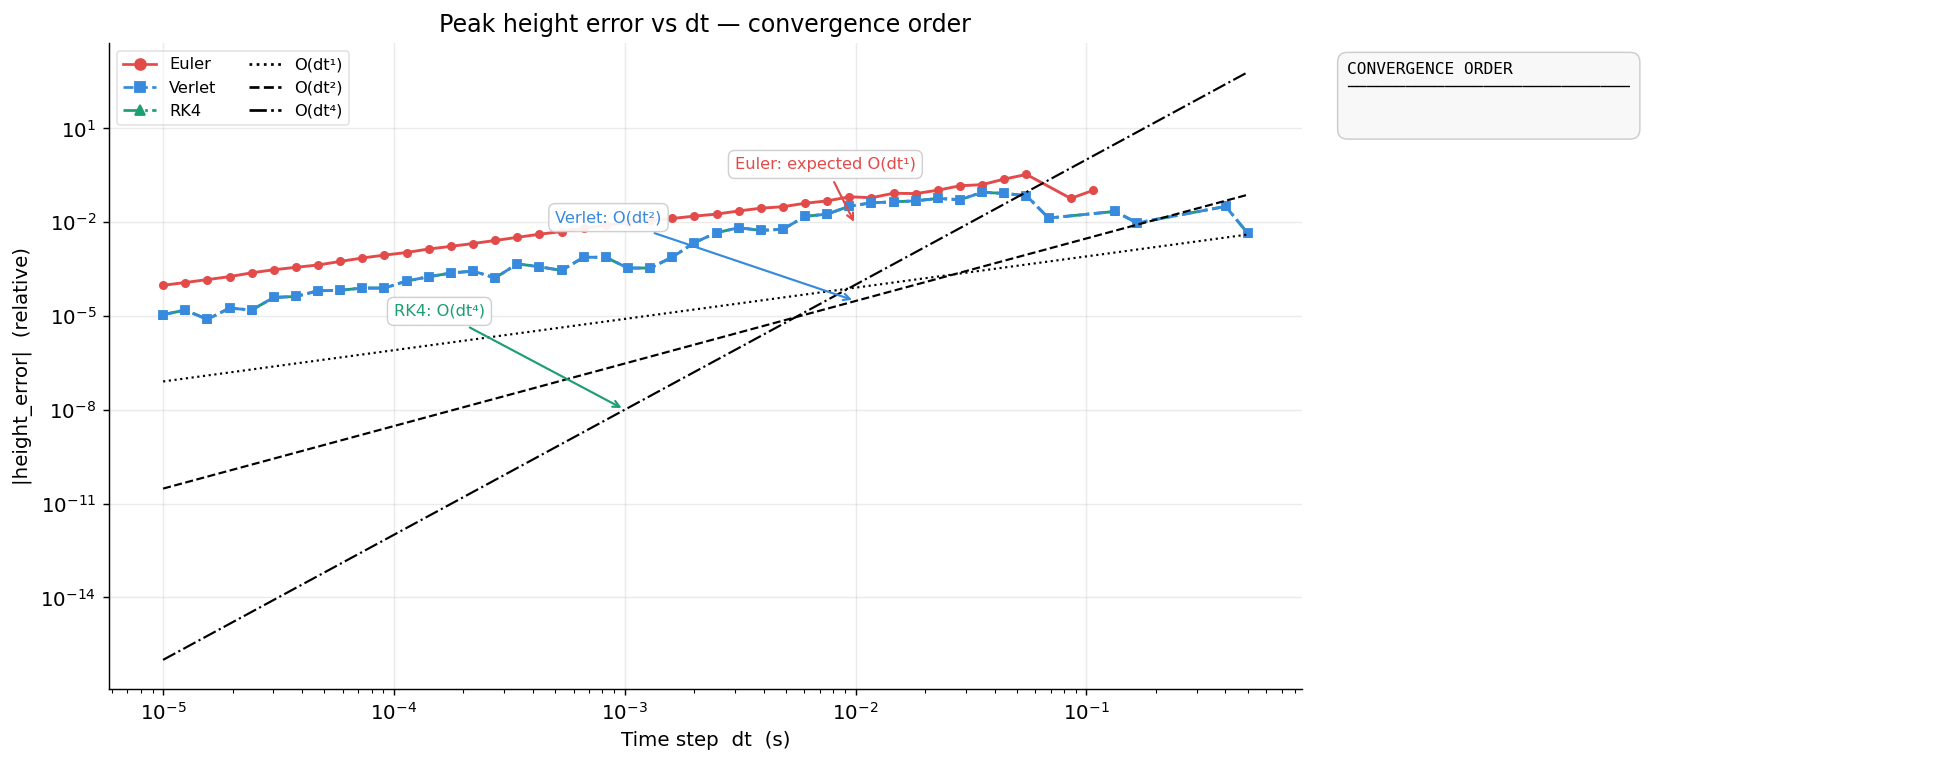

In [2]:
fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    mask = grp["max_height_error"] > 0
    ax.loglog(grp.loc[mask, "dt"], grp.loc[mask, "max_height_error"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.6)

# Reference slopes
dt_ref = np.array([1e-5, 5e-1])
ax.loglog(dt_ref, 8e-3  * dt_ref**1, "k:",  linewidth=1.2, label="O(dt¹)")
ax.loglog(dt_ref, 3e-1  * dt_ref**2, "k--", linewidth=1.2, label="O(dt²)")
ax.loglog(dt_ref, 1e4   * dt_ref**4, "k-.", linewidth=1.2, label="O(dt⁴)")

# Annotations
ax.annotate("Euler: expected O(dt¹)",
            xy=(1e-2, 8e-3), xytext=(3e-3, 5e-1),
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
            color="#E24B4A", fontsize=9, bbox=ABOX)

ax.annotate("Verlet: O(dt²)",
            xy=(1e-2, 3e-5), xytext=(5e-4, 1e-2),
            arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
            color="#378ADD", fontsize=9, bbox=ABOX)

ax.annotate("RK4: O(dt⁴)",
            xy=(1e-3, 1e-8), xytext=(1e-4, 1e-5),
            arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
            color="#1D9E75", fontsize=9, bbox=ABOX)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|height_error|  (relative)")
ax.set_title("Peak height error vs dt — convergence order")

handles_s = [Line2D([0],[0], color=s["color"], marker=s["marker"], ls=s["ls"], label=k, markersize=6)
             for k, s in SOLVER_STYLE.items()]
handles_r = [
    Line2D([0],[0], color="k", ls=":",  label="O(dt¹)"),
    Line2D([0],[0], color="k", ls="--", label="O(dt²)"),
    Line2D([0],[0], color="k", ls="-.", label="O(dt⁴)"),
]
ax.legend(handles=handles_s + handles_r, fontsize=9, framealpha=0.5,
          ncol=2, loc="upper left")

ax_notes.axis("off")
notes = (
    "CONVERGENCE ORDER\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## Estimated convergence order (linear regression on log-log)

In [3]:
print(f"{'Solver':<10} {'Estimated order':>16} {'R²':>8}")
print("-" * 38)

for solver, grp in df.groupby("solver"):
    grp  = grp.sort_values("dt")
    mask = (grp["max_height_error"] > 1e-12) & (grp["max_height_error"] > 0)
    if mask.sum() < 4:
        print(f"{solver:<10} {'not enough points':>16}")
        continue
    log_dt  = np.log10(grp.loc[mask, "dt"])
    log_err = np.log10(grp.loc[mask, "max_height_error"])
    slope, _, r, *_ = stats.linregress(log_dt, log_err)
    print(f"{solver:<10} {slope:>16.3f} {r**2:>8.4f}")

Solver      Estimated order       R²
--------------------------------------
Euler                 0.858   0.9725
RK4                   0.889   0.8555
Verlet                0.889   0.8555


## Plot 2 — Max energy drift vs dt

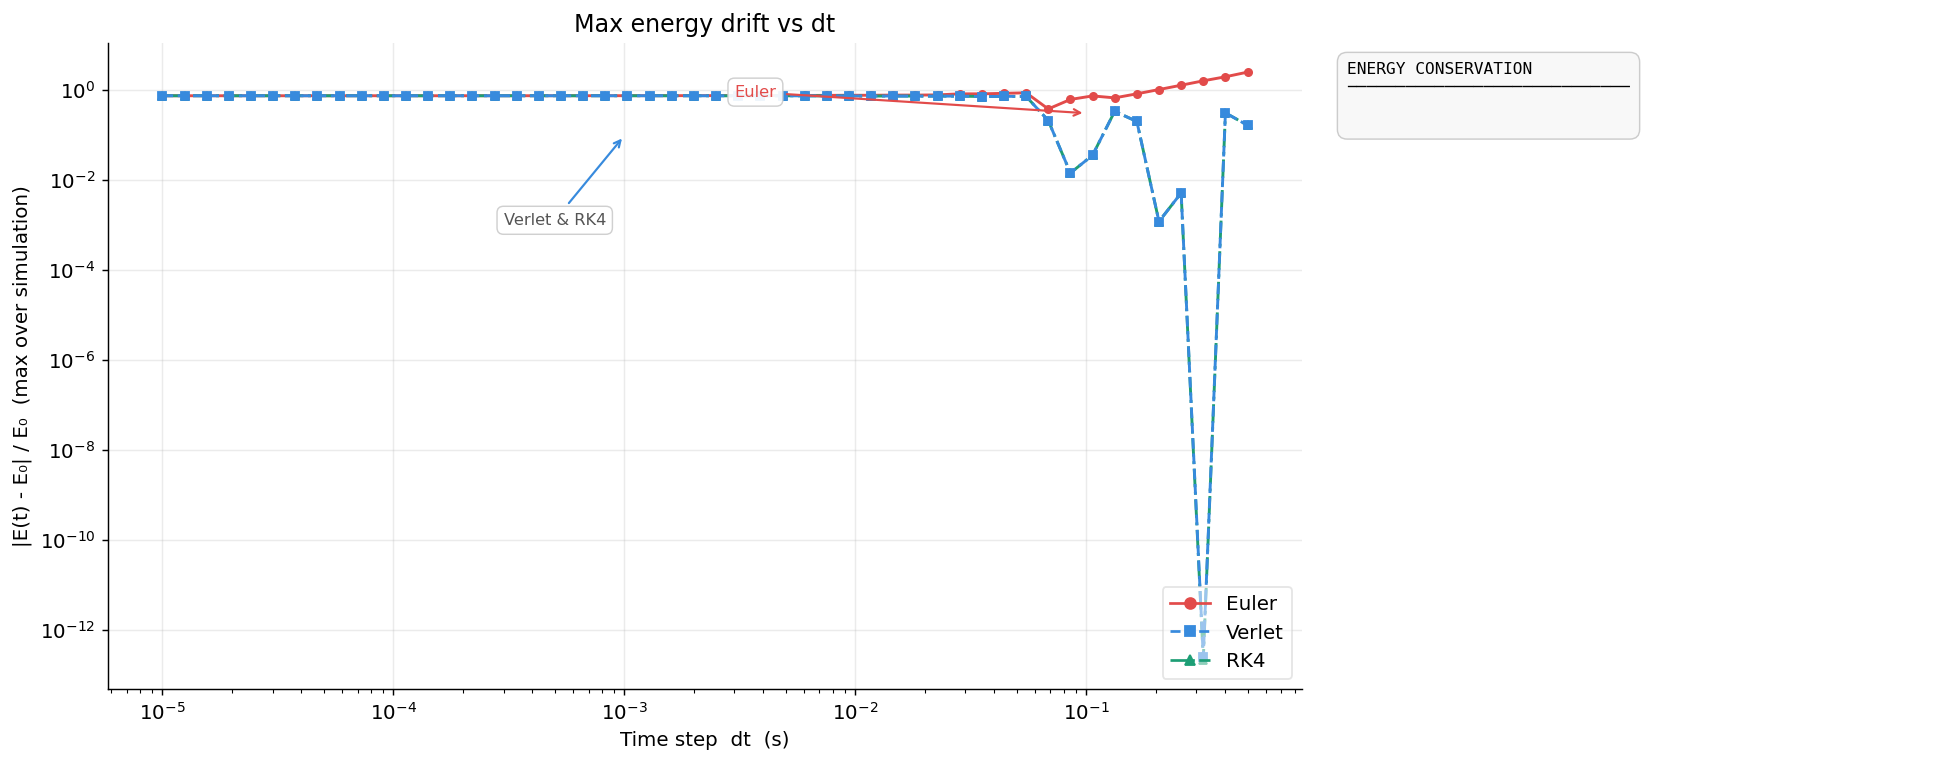

In [4]:
fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    mask = grp["max_energy_drift"] > 0
    ax.loglog(grp.loc[mask, "dt"], grp.loc[mask, "max_energy_drift"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.6)

# Expected floor from restitution: each bounce removes (1-e²) fraction of energy
# After one bounce: ΔE/E0 ≈ (1 - e²) = 1 - 0.81 = 0.19
energy_floor = 1.0 - RESTITUTION**2


ax.annotate("Euler",
            xy=(1e-1, 3e-1), xytext=(3e-3, 7e-1),
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
            color="#E24B4A", fontsize=9, bbox=ABOX)

ax.annotate("Verlet & RK4",
            xy=(1e-3, energy_floor * 0.5), xytext=(3e-4, 1e-3),
            arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
            color="#555", fontsize=9, bbox=ABOX)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|E(t) - E₀| / E₀  (max over simulation)")
ax.set_title("Max energy drift vs dt")
solver_legend(ax, loc="lower right")

ax_notes.axis("off")
notes = (
    "ENERGY CONSERVATION\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_energy_drift_vs_dt.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 3 — Cost vs precision

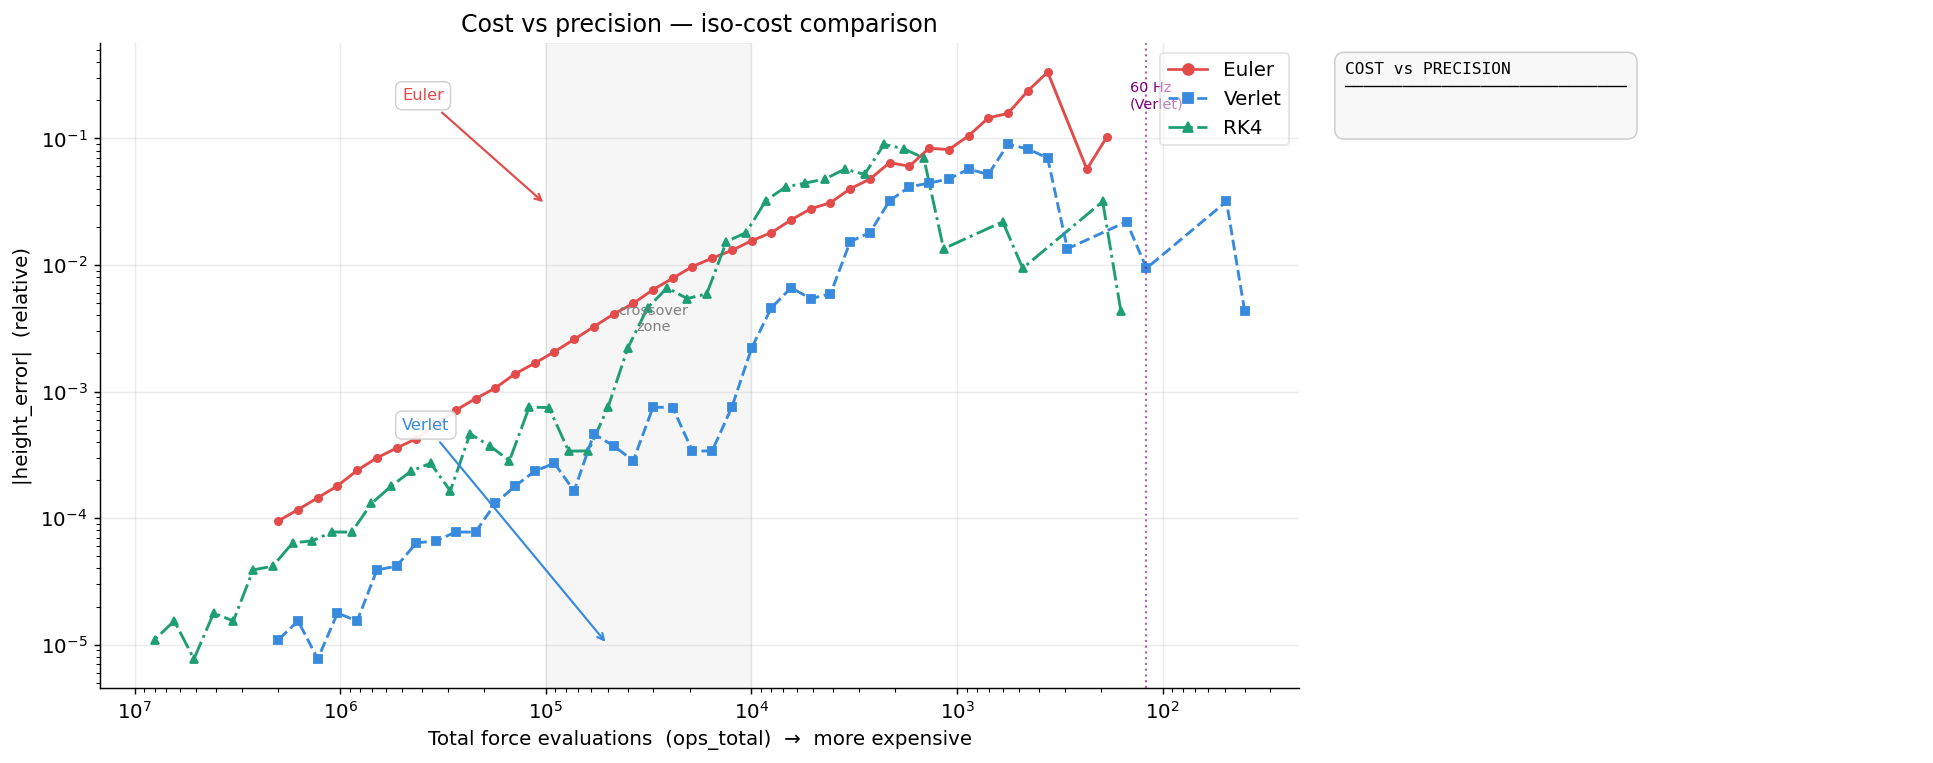

In [5]:
fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("ops_total")
    mask = grp["max_height_error"] > 0
    ax.loglog(grp.loc[mask, "ops_total"], grp.loc[mask, "max_height_error"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.6)

# Crossover region
ax.axvspan(1e4, 1e5, alpha=0.07, color="gray")
ax.text(3e4, 3e-3, "crossover\nzone", fontsize=8, color="gray", ha="center")

ax.annotate("Euler",
            xy=(1e5, 3e-2), xytext=(5e5, 2e-1),
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
            color="#E24B4A", fontsize=9, bbox=ABOX)

ax.annotate("Verlet",
            xy=(5e4, 1e-5), xytext=(5e5, 5e-4),
            arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
            color="#378ADD", fontsize=9, bbox=ABOX)

ax.annotate("RK4",
            xy=(5e2, 1e-7), xytext=(2e3, 5e-5),
            arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
            color="#1D9E75", fontsize=9, bbox=ABOX)

# Game physics reference
ax.axvline(120, color="purple", ls=":", lw=1.2, alpha=0.6)
ax.text(145, ax.get_ylim()[1] * 0.5 if ax.get_ylim()[1] > 0 else 1e-1,
        "60 Hz\n(Verlet)", fontsize=8, color="purple", va="top")

ax.set_xlabel("Total force evaluations  (ops_total)  →  more expensive")
ax.set_ylabel("|height_error|  (relative)")
ax.set_title("Cost vs precision — iso-cost comparison")
ax.invert_xaxis()
solver_legend(ax, loc="upper right")

ax_notes.axis("off")
notes = (
    "COST vs PRECISION\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_cost_vs_precision.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 4 — CPU time vs dt

/tmp/ipykernel_123255/2119847239.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_mid[solver] = float(row["cpu_ms"])
/tmp/ipykernel_123255/2119847239.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_mid[solver] = float(row["cpu_ms"])
/tmp/ipykernel_123255/2119847239.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_mid[solver] = float(row["cpu_ms"])


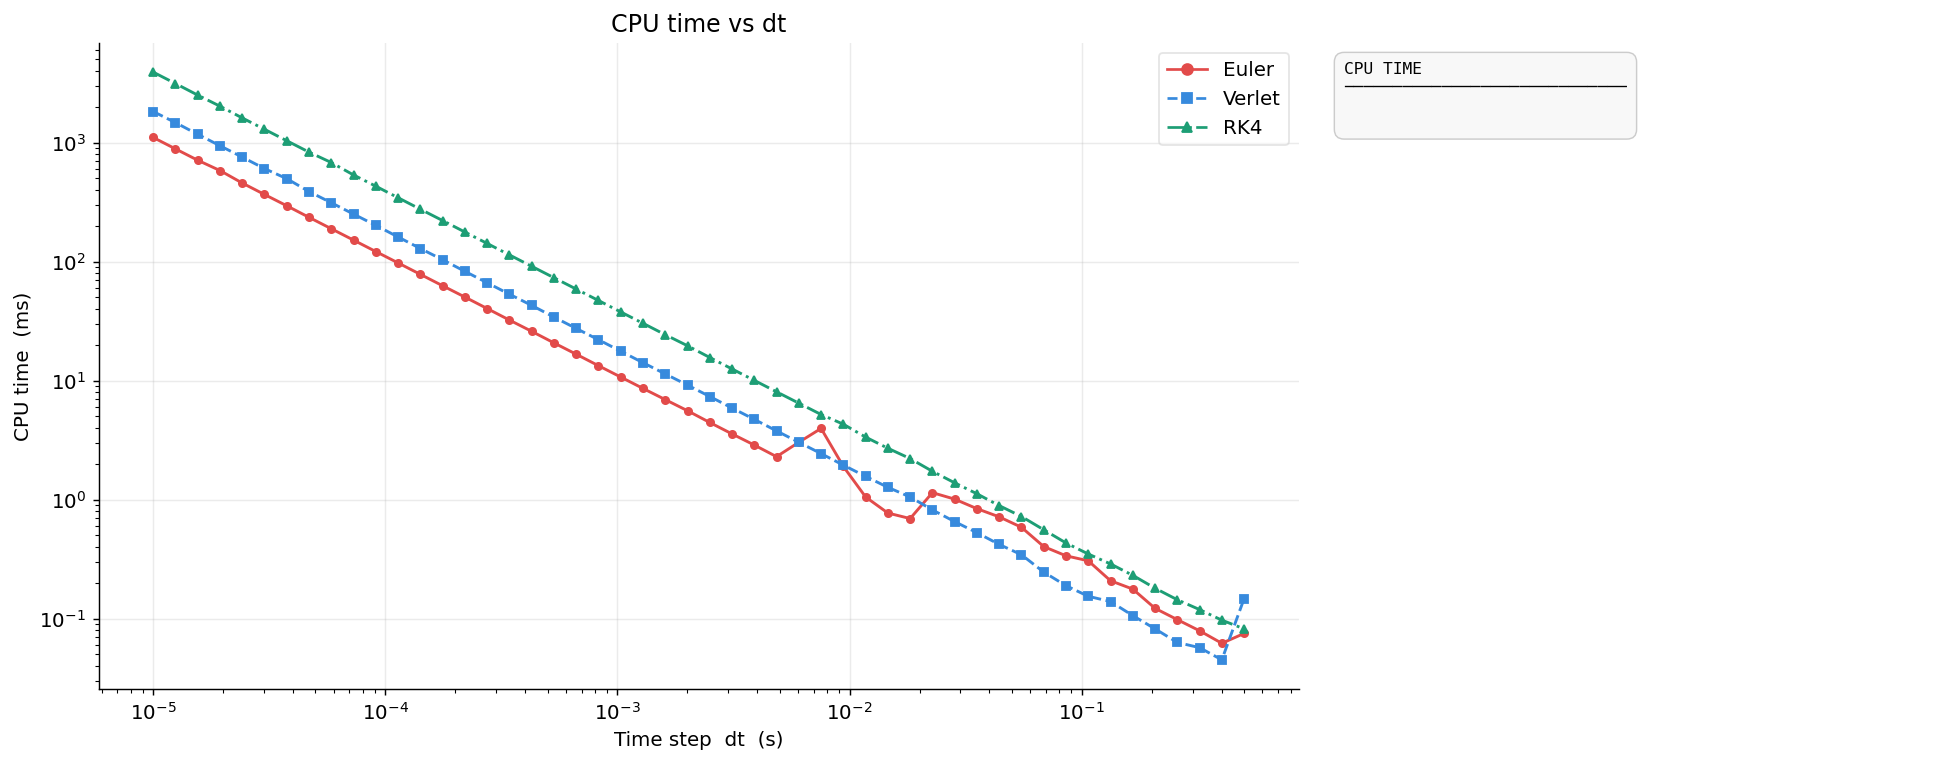

In [6]:
fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    ax.loglog(grp["dt"], grp["cpu_ms"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.6)

# Compute actual cost ratios
mid_dt = df["dt"].median()
cpu_mid = {}
for solver, grp in df.groupby("solver"):
    row = grp.iloc[(grp["dt"] - mid_dt).abs().argsort()[:1]]
    cpu_mid[solver] = float(row["cpu_ms"])

rk4_ratio = cpu_mid["RK4"]    / cpu_mid["Euler"]
vlt_ratio = cpu_mid["Verlet"] / cpu_mid["Euler"]



ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("CPU time  (ms)")
ax.set_title("CPU time vs dt")
solver_legend(ax, loc="upper right")

ax_notes.axis("off")
notes = (
    "CPU TIME\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_cpu_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 5 — Bounce count vs dt (solver stability)

Analytical expected bounces in 20 s: 6


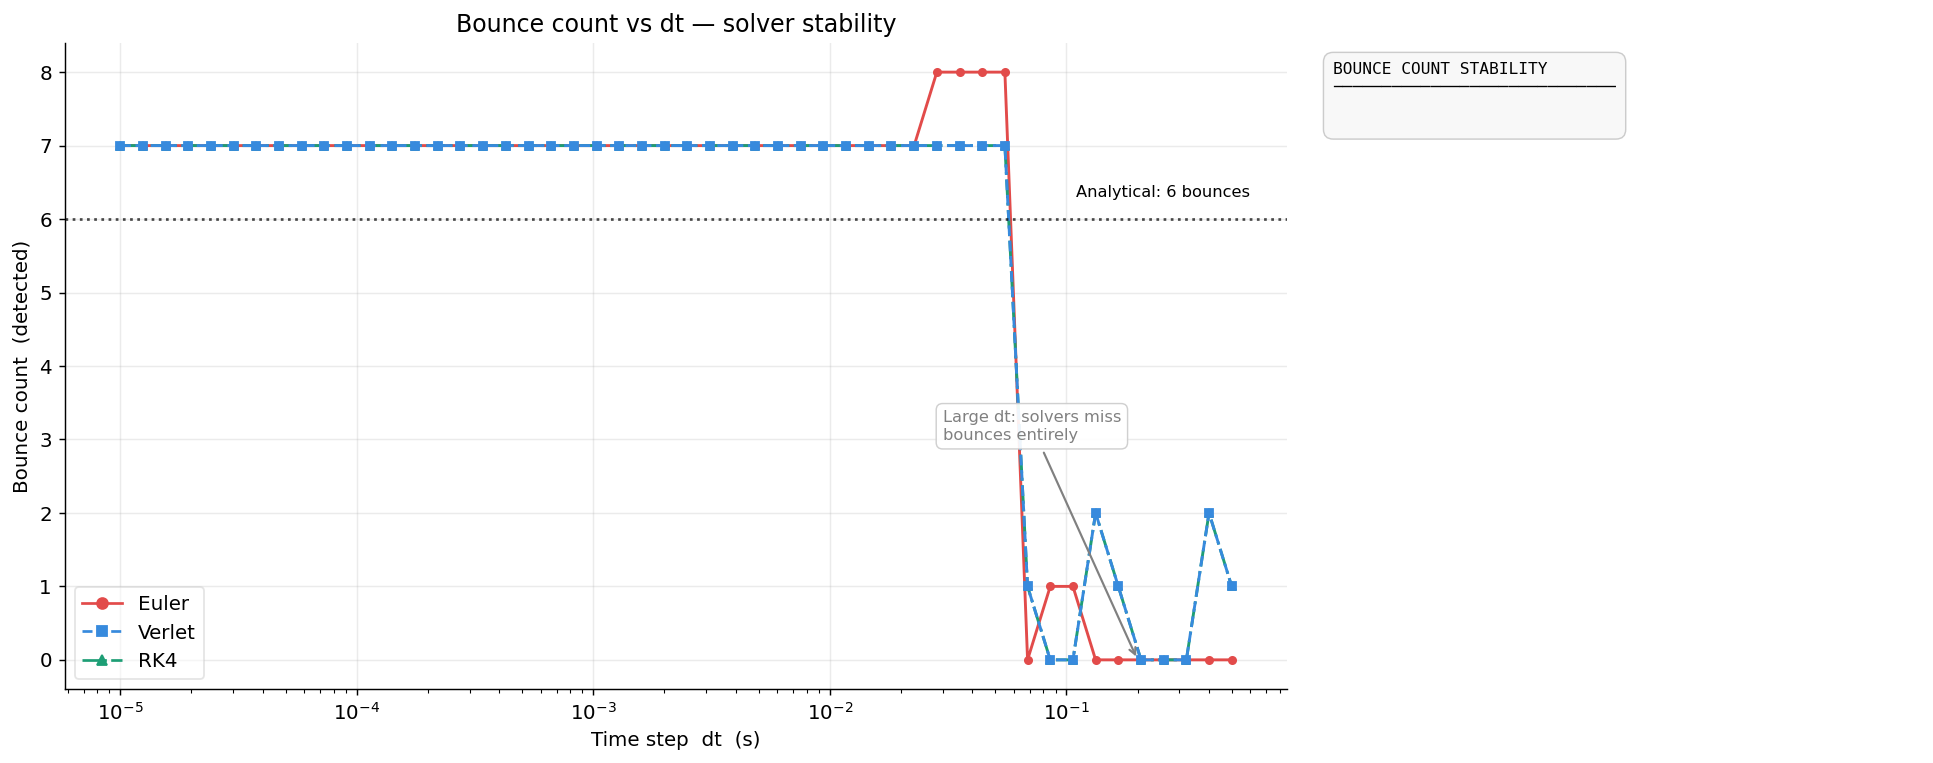

In [7]:
# Analytical expected bounce count given totalTime=20s and restitution=0.9
# Time of nth bounce: sum of flight times up to bounce n
# t_bounce(n) = t_first + 2*sum_{k=1}^{n-1} sqrt(2*h_k/g)
# where h_k = (z0-r)*e^(2k)

def expected_bounces(total_time, z0=Z0, r=RADIUS, e=RESTITUTION, g=G):
    h0_eff = z0 - r
    t = np.sqrt(2 * h0_eff / g)  # time of first contact from rest
    n = 0
    while True:
        h_n = h0_eff * e ** (2 * n)
        flight = 2 * np.sqrt(2 * h_n / g)
        if t + flight > total_time:
            break
        t += flight
        n += 1
    return n

total_time     = df.groupby("solver").apply(lambda g: g["dt"] * (g["ops_total"] / 1)).iloc[0].max()
# Simpler: just read from the first ops_total / opsPerStep * dt
expected_n = expected_bounces(20.0)
print(f"Analytical expected bounces in 20 s: {expected_n}")

fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    ax.semilogx(grp["dt"], grp["bounce_count"],
                color=s["color"], marker=s["marker"], ls=s["ls"],
                markersize=4, linewidth=1.6)

ax.axhline(expected_n, color="black", ls=":", lw=1.5, alpha=0.7)
ax.text(6e-1, expected_n + 0.3, f"Analytical: {expected_n} bounces",
        fontsize=9, ha="right", color="black")

ax.annotate("Large dt: solvers miss\nbounces entirely",
            xy=(2e-1, 0), xytext=(3e-2, 3),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.2),
            color="gray", fontsize=9, bbox=ABOX)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("Bounce count  (detected)")
ax.set_title("Bounce count vs dt — solver stability")
solver_legend(ax, loc="lower left")

ax_notes.axis("off")
notes = (
    "BOUNCE COUNT STABILITY\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_bounce_count.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 6 — E(t) time series

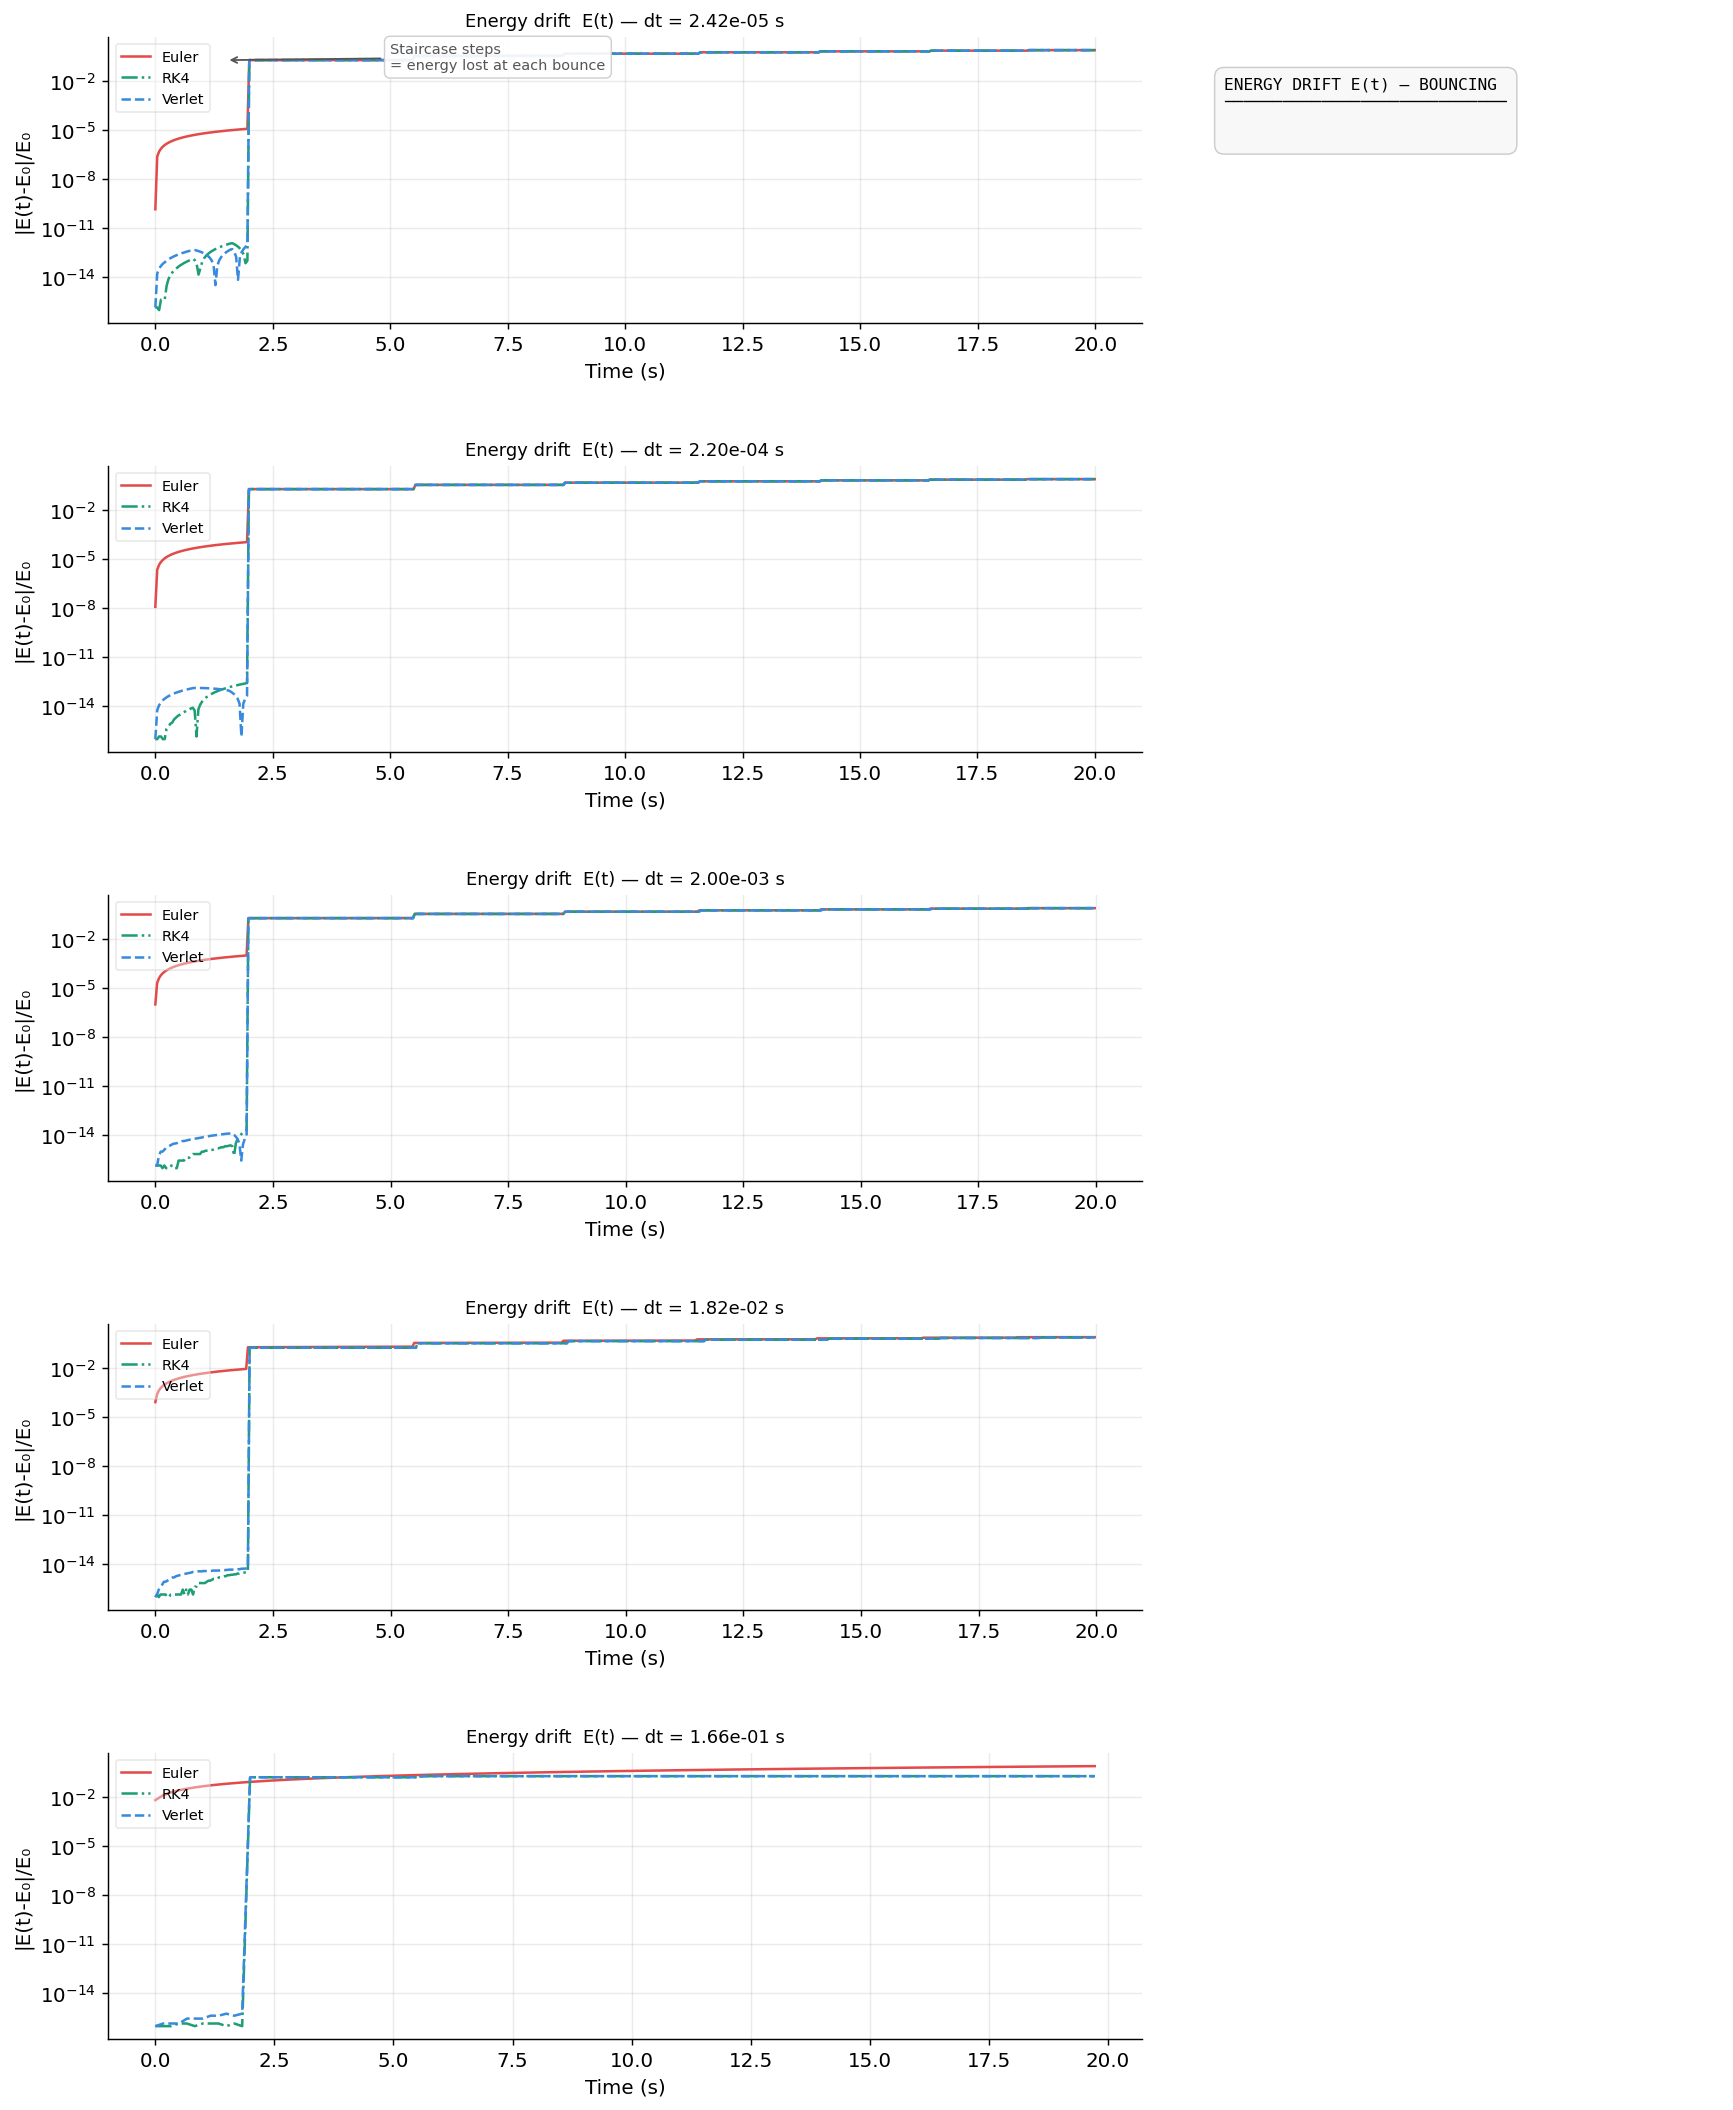

In [8]:
dt_values = sorted(ede["dt"].unique())
n_dt      = len(dt_values)

fig = plt.figure(figsize=(16, 4.0 * n_dt))
gs  = GridSpec(n_dt, 2, figure=fig, width_ratios=[2, 1], hspace=0.5, wspace=0.08)

# Shared notes panel
ax_notes = fig.add_subplot(gs[:, 1])
ax_notes.axis("off")
notes = (
    "ENERGY DRIFT E(t) — BOUNCING\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(0.04, 0.98, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

for i, dt_val in enumerate(dt_values):
    ax = fig.add_subplot(gs[i, 0])
    subset = ede[ede["dt"] == dt_val]

    for solver, grp in subset.groupby("solver"):
        s = SOLVER_STYLE[solver]
        grp = grp.sort_values("time")
        ax.semilogy(grp["time"], grp["energy_drift"].clip(lower=1e-16),
                    color=s["color"], ls=s["ls"], linewidth=1.4, label=solver)

    ax.set_title(f"Energy drift  E(t) — dt = {dt_val:.2e} s", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("|E(t)-E₀|/E₀")
    ax.legend(fontsize=8, framealpha=0.4, loc="upper left")

    if i == 0:
        ax.annotate("Staircase steps\n= energy lost at each bounce",
                    xy=(1.5, 0.18), xytext=(5, 0.05),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1),
                    color="#555", fontsize=8, bbox=ABOX)
       

plt.savefig("plot_energy_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary statistics table

In [9]:
rows = []
for solver, grp in df.groupby("solver"):
    # Best height error (at smallest dt)
    best_row   = grp.loc[grp["dt"].idxmin()]
    worst_row  = grp.loc[grp["dt"].idxmax()]

    # Stability: fraction of dt values with correct bounce count
    stable_pct = (grp["bounce_count"] == expected_n).mean() * 100

    rows.append({
        "Solver":                  solver,
        "Best height error":       f"{best_row['max_height_error']:.2e}",
        "Worst height error":      f"{worst_row['max_height_error']:.2e}",
        "Max energy drift (min dt)": f"{best_row['max_energy_drift']:.2e}",
        "Correct bounce count (%)": f"{stable_pct:.0f}%",
        "CPU @ min dt (ms)":        f"{best_row['cpu_ms']:.1f}",
    })

summary = pd.DataFrame(rows).set_index("Solver")
summary

,Best height error,Worst height error,Max energy drift (min dt),Correct bounce count (%),CPU @ min dt (ms)
Solver,,,,,
Euler,9.49e-05,0.00e+00,7.33e-01,0%,1105.3
RK4,1.09e-05,4.35e-03,7.33e-01,0%,3913.6
Verlet,1.09e-05,4.35e-03,7.33e-01,0%,1825.6


## Export all plots to PDF

In [10]:
from matplotlib.backends.backend_pdf import PdfPages

plot_files = [
    "plot_convergence.png",
    "plot_energy_drift_vs_dt.png",
    "plot_cost_vs_precision.png",
    "plot_cpu_time.png",
    "plot_bounce_count.png",
    "plot_energy_time_series.png",
]

with PdfPages("benchmark_report.pdf") as pdf:
    for path in plot_files:
        img = plt.imread(path)
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF saved to benchmark_report.pdf")

PDF saved to benchmark_report.pdf
